# 03 - 08 Baseline & Architecture Experiments

In [1]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for base in (start, *start.parents):
        if (base / "src" / "config.py").is_file():
            return base
    for child in sorted(c for c in start.iterdir() if c.is_dir()):
        if (child / "src" / "config.py").is_file():
            return child
    raise RuntimeError(f"Could not find the project root from {start}.")


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers

from src.config import IMG_SHAPE, NUM_CLASSES, SEED
from src.data import load_splits
from src.models import validate_model
from src.utils import set_seed

data = load_splits()
print(data.summary())

I0000 00:00:1787392256.459766  133136 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787392257.721628  133136 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787392273.813422  133136 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


X_train  (45000, 32, 32, 3)  float32
X_val    (5000, 32, 32, 3)   float32
X_test   (10000, 32, 32, 3)  float32
y_train  (45000,)            int32
y_val    (5000,)             int32
y_test   (10000,)            int32


## Part 3 - Baseline Neural Network

In [2]:
# These hyperparameters are unchanged across every architecture comparison.
HIDDEN_UNITS = 512
LEARNING_RATE = 0.0001
BATCH_SIZE = 128
EPOCHS = 50

### Hyperparameter choices

**512 neurons.** Chosen by testing. At 32 units the model stalled at 19%
accuracy with 31 of 32 hidden units dead, so ReLU had collapsed the layer to a
single effective neuron. Widths of 64 and above trained normally, and 512 keeps
the first hidden layer wide enough that it compresses the 3072-value input only
six-fold, so the width of that layer is not itself the bottleneck.

**Learning rate 0.0001.** The value Part 9's sweep (0.01 / 0.001 / 0.0001)
selects, adopted here so that every architecture comparison runs at the same
setting the tuned model uses.

**Batch size 128.** Above the range swept in Part 10 (16 / 32 / 64). At 45,000
training images it gives 352 weight updates per epoch.

**50 epochs.** Validation loss reaches its minimum near epoch 42. Extending to
100 epochs gained only 0.4 points of validation accuracy while training accuracy
gained 1.1, which is memorisation rather than learning.


In [3]:
set_seed(SEED)

baseline_model = keras.Sequential(
    [
        keras.Input(shape=IMG_SHAPE),
        layers.Flatten(name="flatten"),
        layers.Dense(HIDDEN_UNITS, activation="relu", name="hidden"),
        layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
    ],
    name="baseline_model",
)

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

validate_model(baseline_model)   # ensures: no Conv2D, 10 outputs, BatchNorm placement
baseline_model.summary()


W0000 00:00:1787392335.467459  133136 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1787392335.470157  133136 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1787392335.650270  133136 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5219 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "baseline_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,506 (6.02 MB)

 Trainable params: 1,578,506 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
trainable = int(sum(np.prod(w.shape) for w in baseline_model.trainable_weights))

print(f"Layers (excluding Input) : {len(baseline_model.layers)}")
print(f"Trainable parameters     : {trainable:,}")
print(f"Hidden activation        : {baseline_model.get_layer('hidden').activation.__name__}")
print(f"Output activation        : {baseline_model.get_layer('output').activation.__name__}")
print(f"Loss function            : {baseline_model.loss}")
print(f"Optimizer                : {type(baseline_model.optimizer).__name__}")
print(f"Learning rate            : {float(baseline_model.optimizer.learning_rate):.4f}")

Layers (excluding Input) : 3
Trainable parameters     : 1,578,506
Hidden activation        : relu
Output activation        : softmax
Loss function            : sparse_categorical_crossentropy
Optimizer                : Adam
Learning rate            : 0.0001


In [5]:
history = baseline_model.fit(
    data.X_train,
    data.y_train,
    validation_data=(data.X_val, data.y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)

Epoch 1/50


I0000 00:00:1787392345.438764  133885 service.cc:153] XLA service 0x7bb64402fe40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787392345.438798  133885 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787392345.526970  133885 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787392345.675712  133885 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787392345.706536  133885 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_957__.12
I0000 00:00:1787392346.852539  133982 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1787392349.649122  133885 device_compiler.h:208] Compiled cluster usin

352/352 - 12s - 35ms/step - accuracy: 0.3324 - loss: 1.8848 - val_accuracy: 0.3762 - val_loss: 1.7654
Epoch 2/50
352/352 - 1s - 2ms/step - accuracy: 0.3971 - loss: 1.7226 - val_accuracy: 0.4098 - val_loss: 1.6959
Epoch 3/50
352/352 - 1s - 2ms/step - accuracy: 0.4243 - loss: 1.6520 - val_accuracy: 0.4260 - val_loss: 1.6516
Epoch 4/50
352/352 - 1s - 2ms/step - accuracy: 0.4404 - loss: 1.6035 - val_accuracy: 0.4324 - val_loss: 1.6218
Epoch 5/50
352/352 - 1s - 2ms/step - accuracy: 0.4536 - loss: 1.5649 - val_accuracy: 0.4422 - val_loss: 1.6023
Epoch 6/50
352/352 - 1s - 2ms/step - accuracy: 0.4653 - loss: 1.5328 - val_accuracy: 0.4496 - val_loss: 1.5771
Epoch 7/50
352/352 - 1s - 2ms/step - accuracy: 0.4743 - loss: 1.5055 - val_accuracy: 0.4554 - val_loss: 1.5614
Epoch 8/50
352/352 - 1s - 2ms/step - accuracy: 0.4840 - loss: 1.4796 - val_accuracy: 0.4648 - val_loss: 1.5454
Epoch 9/50
352/352 - 1s - 2ms/step - accuracy: 0.4948 - loss: 1.4552 - val_accuracy: 0.4708 - val_loss: 1.5273
Epoch 10/5

In [6]:
H = history.history

print(f"Final training accuracy   : {H['accuracy'][-1]:.4f}")
print(f"Final validation accuracy : {H['val_accuracy'][-1]:.4f}")
print(f"Best validation accuracy  : {max(H['val_accuracy']):.4f} (epoch {int(np.argmax(H['val_accuracy']))+1})")
print(f"Lowest validation loss    : {min(H['val_loss']):.4f} (epoch {int(np.argmin(H['val_loss']))+1})")
print(f"Generalization gap        : {H['accuracy'][-1] - H['val_accuracy'][-1]:+.4f}")
print(f"Random-guess baseline     : {1/NUM_CLASSES:.4f}")

Final training accuracy   : 0.6746
Final validation accuracy : 0.5214
Best validation accuracy  : 0.5222 (epoch 44)
Lowest validation loss    : 1.3877 (epoch 42)
Generalization gap        : +0.1532
Random-guess baseline     : 0.1000


In [7]:
RESULTS = ROOT / "Results"
RESULTS.mkdir(exist_ok=True)

record = {
    "name": "baseline",
    "architecture": [HIDDEN_UNITS],
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "optimizer": "adam",
    "dropout": None,
    "batchnorm": False,
    "early_stopping": False,
    "trainable_params": trainable,
    "best_val_accuracy": float(max(H["val_accuracy"])),
    "min_val_loss": float(min(H["val_loss"])),
    "final_train_accuracy": float(H["accuracy"][-1]),
    "history": {k: [float(x) for x in v] for k, v in H.items()},
}
(RESULTS / "baseline.json").write_text(json.dumps(record, indent=2), encoding="utf-8")
print("saved -> Results/baseline.json")

saved -> Results/baseline.json


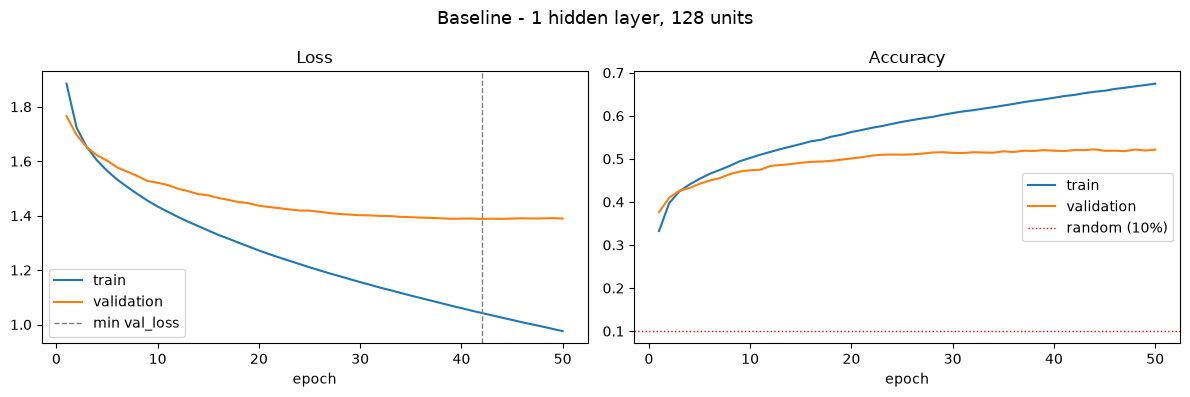

In [8]:
# Read from disk, not from H: the Part 4 save loop rebinds H to the last
# model, so re-running cells out of order would silently plot the wrong run.
Hb = json.loads((RESULTS / "baseline.json").read_text())["history"]
epochs = range(1, len(Hb["loss"]) + 1)

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Baseline - 1 hidden layer, 128 units", fontsize=13)

ax_loss.plot(epochs, Hb["loss"], label="train")
ax_loss.plot(epochs, Hb["val_loss"], label="validation")
ax_loss.axvline(int(np.argmin(Hb["val_loss"])) + 1, ls="--", c="gray", lw=1, label="min val_loss")
ax_loss.set_title("Loss"); ax_loss.set_xlabel("epoch"); ax_loss.legend()

ax_acc.plot(epochs, Hb["accuracy"], label="train")
ax_acc.plot(epochs, Hb["val_accuracy"], label="validation")
ax_acc.axhline(0.1, ls=":", c="red", lw=1, label="random (10%)")
ax_acc.set_title("Accuracy"); ax_acc.set_xlabel("epoch"); ax_acc.legend()

plt.tight_layout(); plt.show()

### Baseline results

0.5222 validation accuracy and a 10% random-guess floor is about 5x the chance.

The generalization gap reaches +0.1524, but validation loss is still falling as
late as epoch 42 and ends only 0.1% above its minimum, so the model is not yet
diverging. The next step is more capacity, not regularization: Dropout cannot
fix a model that has not yet fitted its training data.


### Part 3 answers

> **Why ReLU for the hidden layer?**
>
> It avoids the vanishing gradients that sigmoid and tanh suffer when they saturate. It is also just max(0, z).
> 
> 
>
> The problem that faced us in this project: ReLU outputs zero for negative
> inputs, so a unit pushed there gets zero gradient and never recovers. At 32
> units, 31 were dead and the model maxed at 19%. Increasing neurons to 128 leaves
> enough surviving units.

> **Why Softmax for the output layer?**
>
> The ten classes are mutually exclusive, so the outputs should form one
> probability distribution summing to 1, so raising one class lowers the others.
> Sigmoid would score each class independently, it also would not sum to 1.

> **Why this loss function?**
>
> Cross-entropy is -log(p) for the true class, so a confident wrong prediction
> is punished hard. MSE would treat the outputs as arbitrary numbers, penalise
> errors far more gently, and give a flatter gradient through softmax.
>
> Sparse cross-entropy because our labels are integers of shape (45000,), not
> one-hot. Identical mathematically to plain cross-entropy.

## Part 4 - Architecture Experiment

In [9]:
ARCHITECTURES = {
    "shallow": [512],
    "medium":  [512, 512, 512],
    "deep":    [512, 512, 512, 512, 512],
}

In [10]:
def build_model(name, hidden_units):
    #Same seed, same optimizer, same loss, only number of hidden layers differ.
    set_seed(SEED)

    net = [keras.Input(shape=IMG_SHAPE), layers.Flatten(name="flatten")]
    for i, units in enumerate(hidden_units, start=1):
        net.append(layers.Dense(units, activation="relu", name=f"hidden_{i}"))
    net.append(layers.Dense(NUM_CLASSES, activation="softmax", name="output"))

    model = keras.Sequential(net, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    validate_model(model)
    return model

In [11]:
models = {}
for name, units in ARCHITECTURES.items():
    models[name] = build_model(name, units)
    print(f"\n{'='*70}\n{name.upper()}  -  {len(units)} hidden layer(s), units {units}\n{'='*70}")
    models[name].summary()

print(f"\n{'Model':<10}{'Hidden layers':>15}{'Trainable params':>20}")
for name, m in models.items():
    print(f"{name:<10}{len(ARCHITECTURES[name]):>15}{m.count_params():>20,}")


SHALLOW  -  1 hidden layer(s), units [512]


Model: "shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,506 (6.02 MB)

 Trainable params: 1,578,506 (6.02 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,629,130 (10.03 MB)

 Trainable params: 2,629,130 (10.03 MB)

 Non-trainable params: 0 (0.00 B)


Model       Hidden layers    Trainable params
shallow                 1           1,578,506
medium                  3           2,103,818
deep                    5           2,629,130


## Part 5 - Fair Model Comparison

In [12]:
histories = {}
for name, model in models.items():
    print(f"training {name} ...")
    histories[name] = model.fit(
        data.X_train, data.y_train,
        validation_data=(data.X_val, data.y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    ).history
    H = histories[name]
    print(f"  best val_acc {max(H['val_accuracy']):.4f} | "
          f"min val_loss {min(H['val_loss']):.4f} | "
          f"gap {H['accuracy'][-1] - H['val_accuracy'][-1]:+.4f}")

training shallow ...


I0000 00:00:1787392542.584237  133885 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_81995__.12
I0000 00:00:1787392543.992744  133882 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_81995__.12


  best val_acc 0.5222 | min val_loss 1.3877 | gap +0.1532
training medium ...


I0000 00:00:1787392587.375737  133881 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_163266__.14
I0000 00:00:1787392588.236234  140718 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1787392590.920379  133884 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_163266__.14
I0000 00:00:1787392591.160260  140813 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1787392591.405472  140811 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1787392592.469440  140816 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'g

  best val_acc 0.5240 | min val_loss 1.4024 | gap +0.2993
training deep ...


I0000 00:00:1787392638.310108  133881 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_245131__.16
I0000 00:00:1787392640.099221  133885 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_245131__.16


  best val_acc 0.5298 | min val_loss 1.3968 | gap +0.3849


In [13]:
for name, H in histories.items():
    record = {
        "name": name,
        "architecture": ARCHITECTURES[name],
        "hidden_layers": len(ARCHITECTURES[name]),
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "optimizer": "adam",
        "dropout": None,
        "batchnorm": False,
        "early_stopping": False,
        "trainable_params": int(models[name].count_params()),
        "best_val_accuracy": float(max(H["val_accuracy"])),
        "min_val_loss": float(min(H["val_loss"])),
        "final_train_accuracy": float(H["accuracy"][-1]),
        "history": {k: [float(x) for x in v] for k, v in H.items()},
    }
    (RESULTS / f"{name}.json").write_text(json.dumps(record, indent=2), encoding="utf-8")
print("saved ->", ", ".join(f"Results/{n}.json" for n in histories))

saved -> Results/shallow.json, Results/medium.json, Results/deep.json


## Part 6 - Learning Curves

In [14]:
def plot_curves(name):
    hist = histories[name]
    epochs = range(1, len(hist["loss"]) + 1)
    best = int(np.argmin(hist["val_loss"])) + 1

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{name.capitalize()}: {len(ARCHITECTURES[name])} hidden layer(s), 128 units",
                 fontsize=13)

    ax_loss.plot(epochs, hist["loss"], label="train")
    ax_loss.plot(epochs, hist["val_loss"], label="validation")
    ax_loss.axvline(best, ls="--", c="gray", lw=1, label=f"min val_loss (ep {best})")
    ax_loss.set_title("Loss"); ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("loss"); ax_loss.legend()

    ax_acc.plot(epochs, hist["accuracy"], label="train")
    ax_acc.plot(epochs, hist["val_accuracy"], label="validation")
    ax_acc.axhline(0.1, ls=":", c="red", lw=1, label="random (10%)")
    ax_acc.set_title("Accuracy"); ax_acc.set_xlabel("epoch"); ax_acc.set_ylabel("accuracy"); ax_acc.legend()

    plt.tight_layout()
    plt.show()

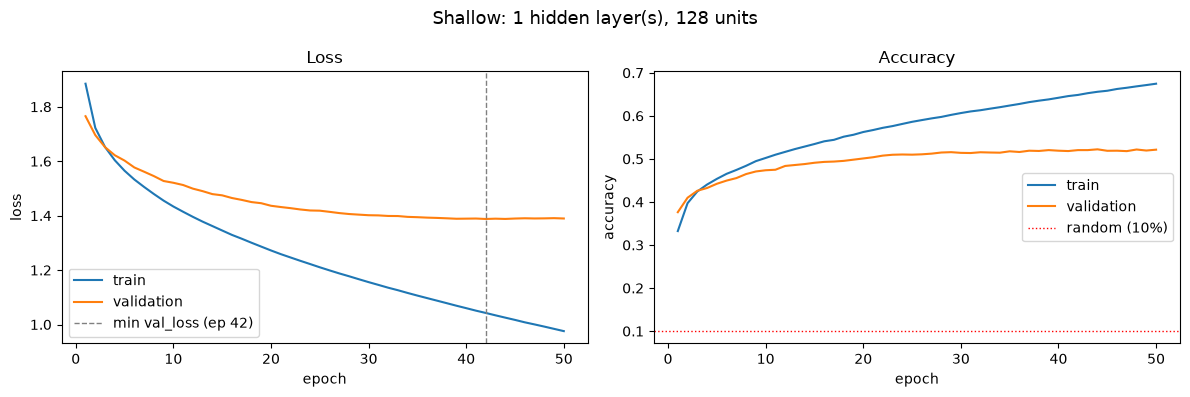

In [15]:
plot_curves("shallow")

**Shallow: underfitting.**

Curves separate to a gap of 0.1524 and validation accuracy plateaus near 52%.
Validation loss bottoms at epoch 42 and ends at 1.3896 against a minimum of
1.3877, so it never meaningfully rises. Not memorising, just too small to fit
the data as well as the deeper models.


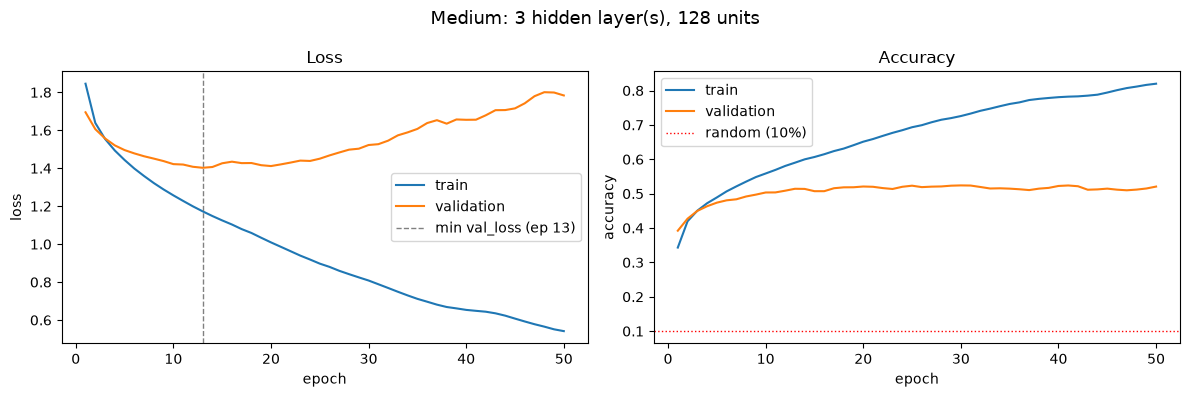

In [16]:
plot_curves("medium")

**Medium: good fit early, then overfitting.**

Validation loss bottoms at epoch 13 (1.4024) and rises 27% to 1.7835, while
training loss keeps falling. Gap 0.0759 at that epoch. The first 13 epochs are
learning, the rest is memorisation.


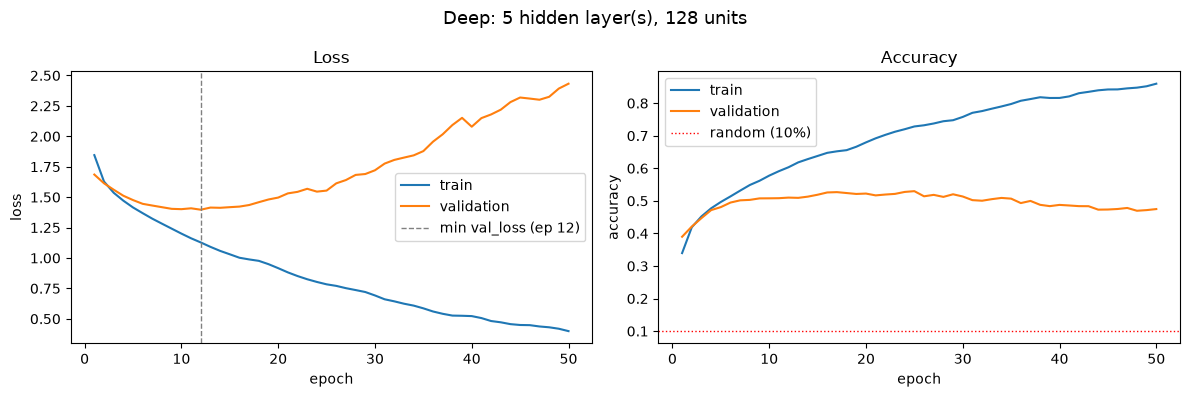

In [17]:
plot_curves("deep")

**Deep: strongest overfitting.**

Validation loss bottoms at epoch 12 (1.3968) then rises 74% to 2.4324, the
largest of the three. Highest training accuracy (0.8597), widest gap (0.3299),
and although its minimum validation loss edges medium's (1.3968 against 1.4024),
it ends far above it.


## Part 7 - Architecture Comparison

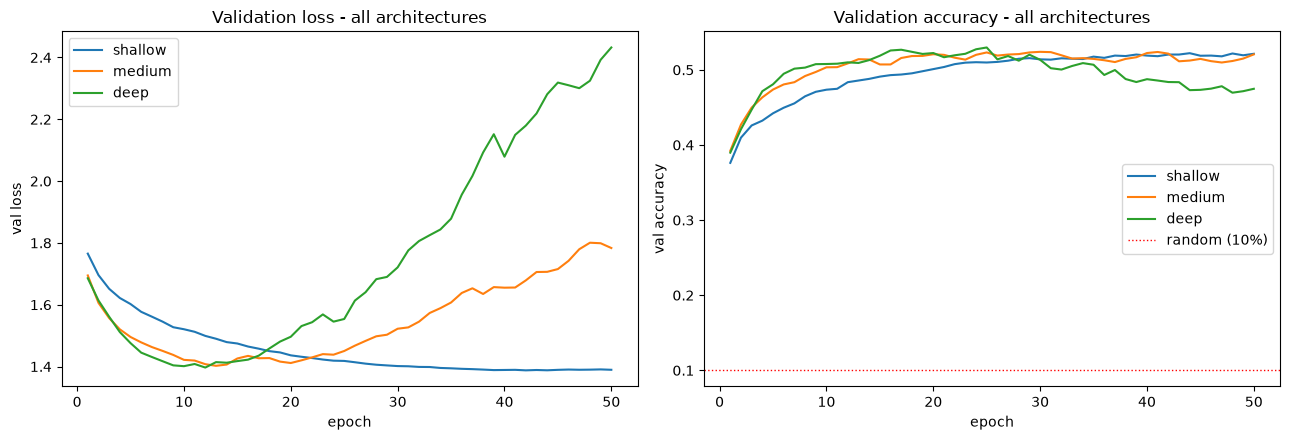

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, hist in histories.items():
    epochs = range(1, len(hist["loss"]) + 1)
    axes[0].plot(epochs, hist["val_loss"], label=name)
    axes[1].plot(epochs, hist["val_accuracy"], label=name)

axes[0].set_title("Validation loss - all architectures"); axes[0].set_ylabel("val loss")
axes[1].set_title("Validation accuracy - all architectures"); axes[1].set_ylabel("val accuracy")
axes[1].axhline(0.1, ls=":", c="red", lw=1, label="random (10%)")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend()

plt.tight_layout()
plt.show()

In [19]:
table = pd.DataFrame([{
    "Model": name.capitalize(),
    "Hidden Layers": len(ARCHITECTURES[name]),
    "Parameters": f"{models[name].count_params():,}",
    "Best Train Acc.": round(max(hist["accuracy"]), 4),
    "Best Val Acc.": round(max(hist["val_accuracy"]), 4),
    "Min Val Loss": round(min(hist["val_loss"]), 4),
    "Min Val Loss Epoch": int(np.argmin(hist["val_loss"])) + 1,
    "Gap": round(max(hist["accuracy"]) - max(hist["val_accuracy"]), 4),
} for name, hist in histories.items()])

display(table)

,Model,Hidden Layers,Parameters,Best Train Acc.,Best Val Acc.,Min Val Loss,Min Val Loss Epoch,Gap
0,Shallow,1,"1,578,506",0.6746,0.5222,1.3877,42,0.1524
1,Medium,3,"2,103,818",0.8199,0.5240,1.4024,13,0.2959
2,Deep,5,"2,629,130",0.8597,0.5298,1.3968,12,0.3299


### Part 7 answers

> **Which architecture learned the Training Data best?**
>
> Deep, at 0.8597. Training accuracy increased with depth.

> **Which architecture achieved the best Validation performance?**
>
> Deep is nominally highest at 0.5298, but the three span only 0.0076
> (38 images out of 5,000), which is inside the noise of the validation set.
> Validation loss ranks them differently again, lowest for shallow at 1.3877
> against deep's 1.3968 and medium's 1.4024, so no architecture is measurably
> the strongest performer.

> **Which model showed the largest gap between Training and Validation?**
>
> Deep at 0.3299.

> **Did increasing depth always improve performance?**
>
> No. Going from 1 to 3 layers gained 0.18 points and 3 to 5 gained 0.58, both
> far inside the noise of a 5,000-image validation set, while the gap more than
> doubled from 0.1524 to 0.3299. Preliminary testing at 10 hidden layers degraded
> the model further, with training accuracy falling despite the extra
> parameters, indicating that depth eventually makes optimization harder rather
> than improving representation.


> **Which model showed the strongest evidence of overfitting?**
>
> Deep. Highest training accuracy, largest gap, and validation loss bottoming
> at epoch 12 then rising for 38 epochs while training loss kept falling.

> **Which architecture will you continue with in the next stage?**
>
> Medium, 3 hidden layers of 512 units.

> **Why did you select it?**
>
> Validation accuracy is tied with shallow and deep within noise, so the choice
> rests on the other columns. Medium holds a smaller gap than deep, 0.2959
> against 0.3299, with 525,312 fewer parameters, and unlike shallow it shows a
> clear overfitting signal for the regularization experiments in Parts 12 and 13
> to act on.


## Part 8 - Model Diagnosis

Selected model: **Medium**, 3 hidden layers of 512 neurons, 2,103,818 parameters.

### Observation

Training loss decreases steadily across all 50 epochs, from 1.845 to 0.542, and
training accuracy increases from 0.343 to 0.820. Validation behaves differently: it
improves for only the first 13 epochs, reaching a minimum loss of 1.4024, then
reverses and rises to 1.7835 by epoch 50, an increase of 27.2%. Validation
accuracy maxes at 0.5240 on epoch 30 and falls down to 0.5206.

The two curves therefore move in opposite directions for most of training, and
the gap widens from 0.0759 at the best epoch to 0.2993 at the final one.

### Diagnosis

**Overfitting**, beginning around epoch 13.

Not underfitting: the model reaches 0.820 training accuracy and its training
loss is still falling at epoch 50, so it clearly has the capacity to keep
fitting the data. Not optimization instability either: the curves are smooth,
with epoch-to-epoch validation loss varying by only 0.016 and a largest single
jump of 0.089.

### Evidence

1. Validation loss reaches its minimum at epoch 13 and rises steadily
   afterwards (1.402, 1.412, 1.522, 1.655, 1.784 at epochs 13, 20, 30, 40, 50)
   while training loss continues to fall over the same span.
2. Validation accuracy peaks at epoch 30 and then declines, so the remaining 20
   epochs make the model actively worse on unseen data.
3. The generalization gap widens as training continues, from 0.0759 to 0.2993.

Together these show the model is learning patterns specific to the training set
rather than ones that generalize.

### First Proposed Improvement

**Early Stopping on validation loss, with the best weights restored.**

This responds directly to the observation: the best model already exists at
epoch 13, and every epoch after it degrades validation performance. Early
stopping recovers that model at no cost, needs no change to the architecture,
and would improve validation loss from 1.7835 to 1.4024.

It treats the symptom rather than the cause, so the natural follow-up is
Dropout, which would let the model train longer before diverging.

Learning rate is deliberately not proposed first: the curves show no
oscillation, so there is no evidence that the step size is the problem.
